# 05 — Least-cost corridors: northern IPCAs + PAs

Routes **least-cost corridors** connecting the proposed northern IPCAs and existing PAs across
northern BC + Yukon — the connection tool the prioritizr connectivity penalty could not be
(that aggregates permeable land; this *routes* between nodes). **Resistance = a weighted blend
of corridor drivers** (transboundary connectivity current-density, climate corridors, climate
refugia) behind a gHM barrier; nodes joined by a minimum spanning tree of least-cost paths.

Runs every **driver-stretch scenario** in `config.CORRIDORS["north"]["scenarios"]` as a full
solve — each with its own **near-optimal ensemble**, so the anchor choice can be judged on
*robustness*, not just on the baseline route. Outputs → `output_data/corridors_north/`
(primary at the top level, one subdir per scenario).

Standalone from the optimizer (03/04). **Kernel:** `.venv` (Python). Ethan runs cell-by-cell.

In [1]:
# ---- Setup: the corridor engine + this analysis' key -----------------------
import importlib
import corridors_core as cc, config
importlib.reload(config); importlib.reload(cc)

KEY = "north"                 # config.CORRIDORS[KEY]
A = cc.load(KEY)              # connectivity + gHM layers, north crop, assemble anchor nodes

Northern BC + Yukon: working grid 1286x1730 = 751,614 PU cells @ 1 km | layers: transboundary_connectivity, climate_corridors, climate_type_macrorefugia, human_modification
  merged node: IPCA · Peel Watershed - SMA/WA absorbs Teetł’it Gwinjik (Peel River) (4,143 km² nested)
  merged node: PA · Nj ‘Iinlii” Jjik (Fishing Branch) Habitat Protection Area absorbs Fishing Branch Wilderness Preserve (5,353 km² nested)
  merged node: PA · Neah Conservancy absorbs Ne'ah – Horseranch Range Deadwood Lake Protected Area (2,293 km² nested)
nodes: 42 (10 IPCAs + 32 existing PAs >= 200 km²)
  dropped 2 IPCA(s) with < 25 PU cells in region: Wëdzey Nähuzhi (Matson Uplands), Łuk Tthe K’ät (Scottie Creek Wetlands)
  node land: 224,679 km² (excluded from the corridor)


In [2]:
# ---- Solve every driver-stretch scenario end to end -------------------------
# Each scenario in config.CORRIDORS[KEY]["scenarios"] gets the full treatment:
#   resistance -> cost distances -> MST corridor network -> near-optimal ensemble.
# Watch per scenario: all nodes should land in 1 network group (fully connected).
#
# SLOW cell: ~n_scenarios x (n_nodes + n_runs x n_nodes) MCP passes -- with 2 scenarios
# that is roughly twice the old single ensemble, so several minutes.
#
# The PRIMARY scenario is restored onto A afterwards, so cc.map(A) / cc.write_outputs(A)
# below behave exactly as they do for a single run.
cc.run_scenarios(A)


=== scenario p1_p99  (primary) {'lo_pctile': 1, 'pctile': 99} ===
  driver transboundary_connectivity   w=0.50  scaled[minmax] p50=0.31 p95=0.73
  driver climate_corridors            w=0.30  scaled[minmax] p50=0.48 p95=0.77
  driver climate_type_macrorefugia    w=0.20  scaled[minmax] p50=0.53 p95=0.92
resistance: p5=2.48 p50=6.11 p95=27.1 max=1645   (low = preferred corridor land)
cost-weighted distance computed from 42 nodes
MST: 41 edges (29 between separated nodes) | corridor (new land) 18,188 cells = 18,188 km² | raw swath incl. node land 19,535 km²
anchors connected: 42 nodes in 1 network group(s) (1 = fully connected)
ensemble: 12 runs (jitter ±20%) | robust core (freq≥0.9) 14,066 km² of 22,846 km² ever-used
  all runs fully connected: True | centre-line length vs optimum: -1%..+2%
  3 distinct near-optimal alternatives (route overlap w/ baseline):
     -1.4% length | 77% overlap
     +0.9% length | 82% overlap
     +1.3% length | 83% overlap

=== scenario p5_p95 {'lo_pctile': 5

<corridors north | 42 nodes | 1286x1730 | corridor 18,188 km² | scenarios: p1_p99, p5_p95>

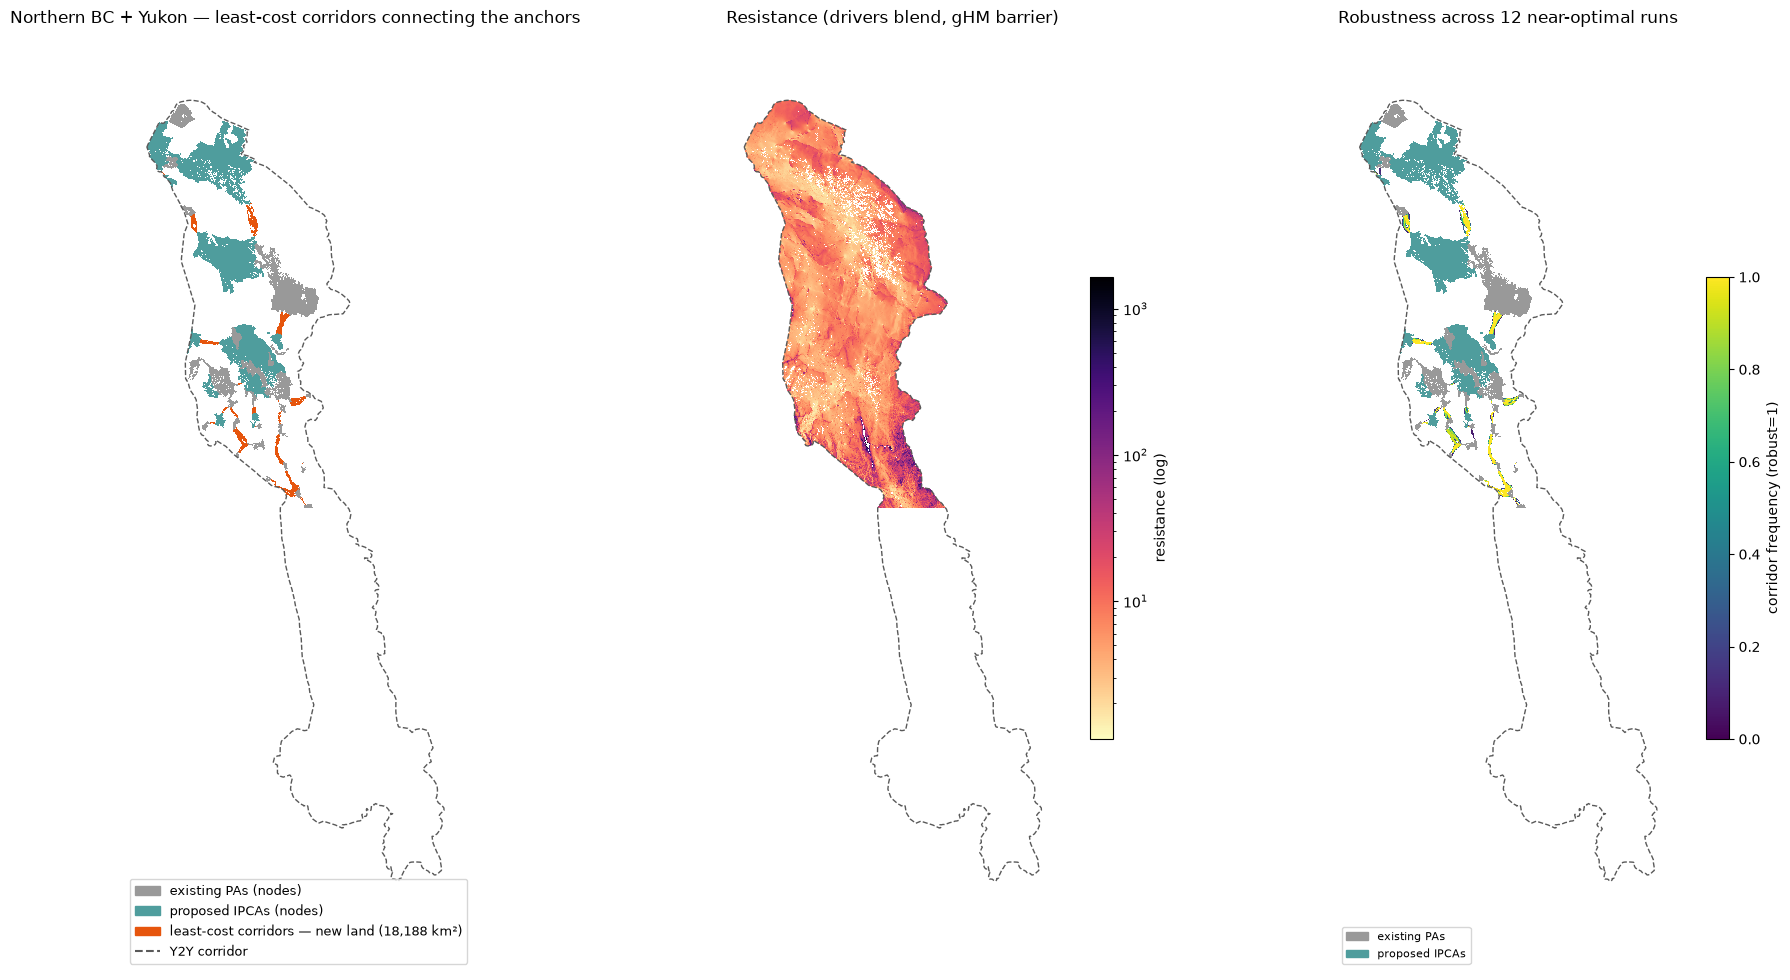

<corridors north | 42 nodes | 1286x1730 | corridor 18,188 km² | scenarios: p1_p99, p5_p95>

In [3]:
# ---- Map: corridors over PAs + IPCAs (+ resistance panel) ----
cc.map(A)

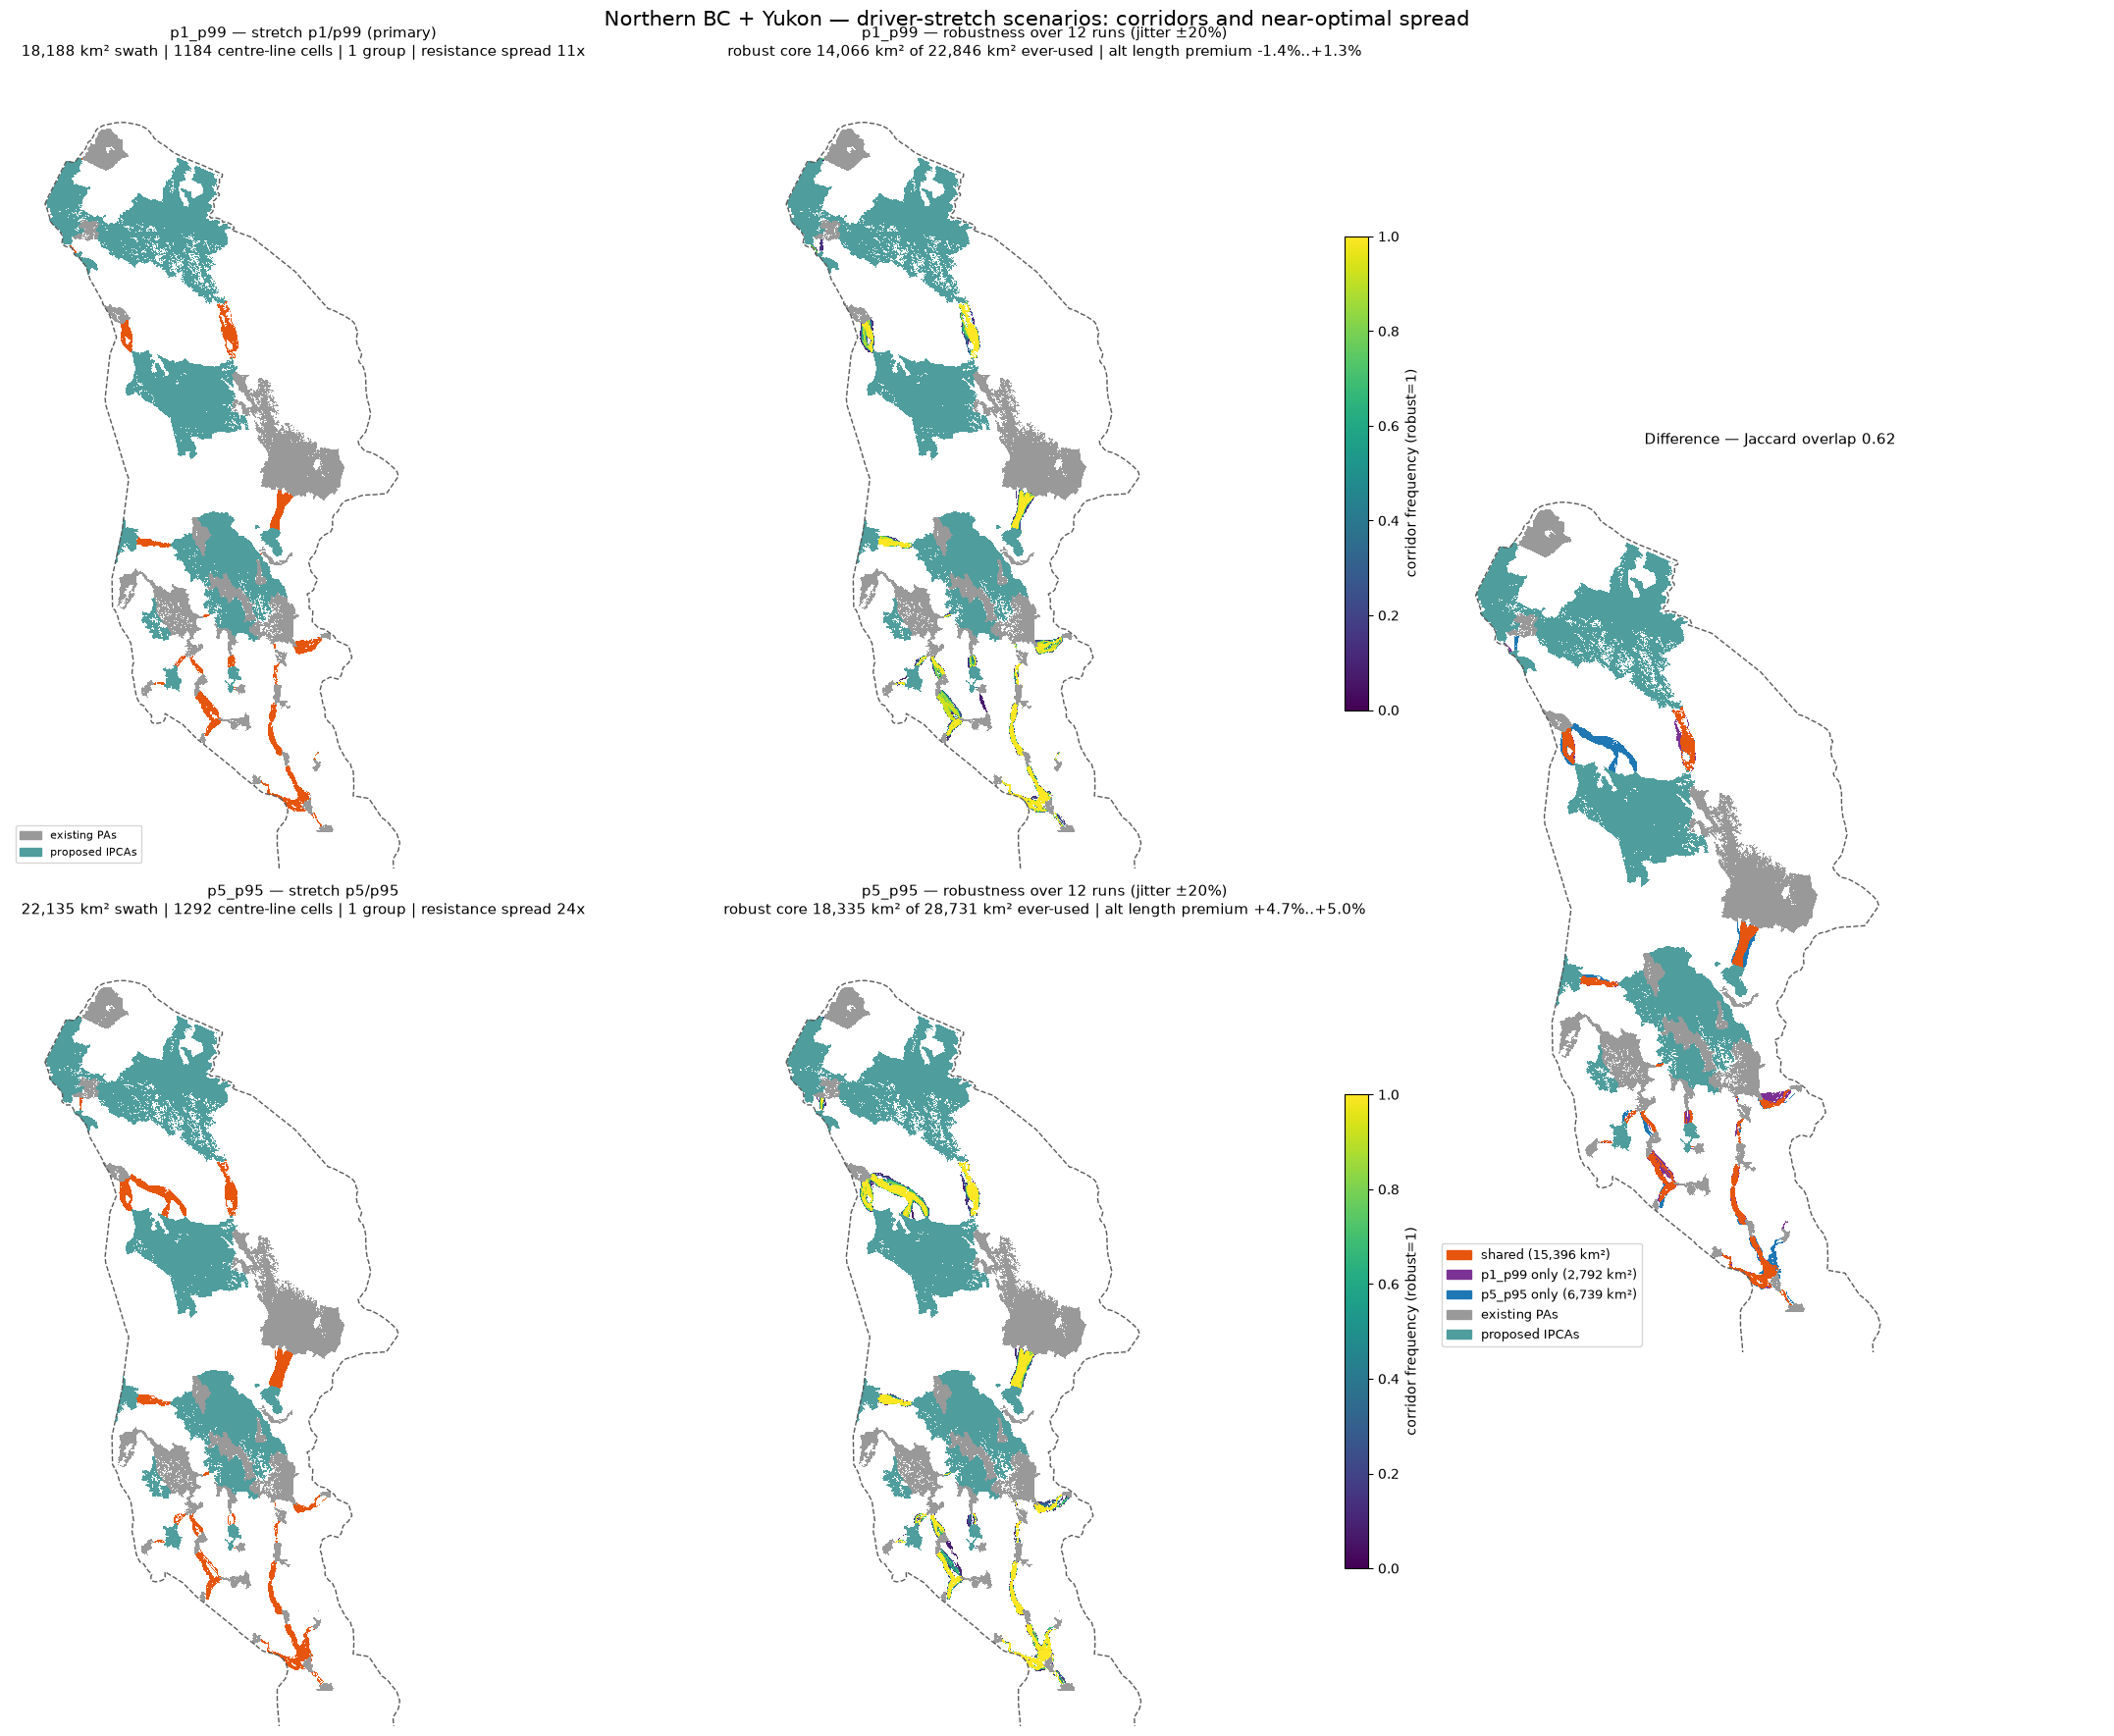

<corridors north | 42 nodes | 1286x1730 | corridor 18,188 km² | scenarios: p1_p99, p5_p95>

In [4]:
# ---- Scenario comparison: corridors + near-optimal spread, side by side ----
# One row per scenario (corridor swath | ensemble robustness), plus a difference panel.
# A link that MOVES between scenarios should also read as low-frequency in the robustness
# panel -- when both agree, that stretch of route is genuinely negotiable rather than a
# modelling artifact. Resistance surfaces are in the next cell, kept separate for clarity.
cc.compare_map(A)

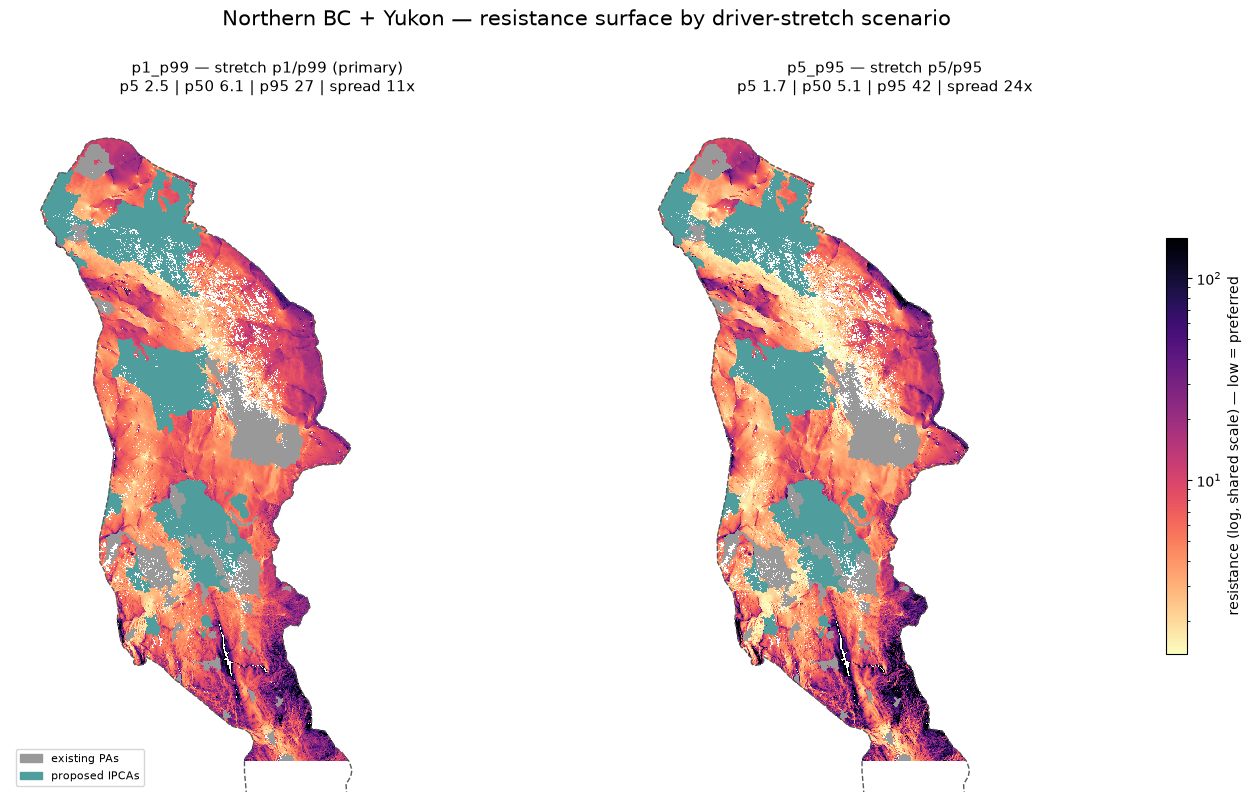

<corridors north | 42 nodes | 1286x1730 | corridor 18,188 km² | scenarios: p1_p99, p5_p95>

In [5]:
# ---- Resistance surfaces, side by side -------------------------------------
# SHARED log colour scale, so the two surfaces are directly comparable: p5/p95 runs
# darker at both ends (24x spread) than p1/p99 (11x) -- that contrast is exactly what
# pins its routes and makes its alternatives cost ~5% more.
cc.compare_resistance(A)

corridor segments: 23 components merged by location into 10 clusters (100% of corridor area — all of it)
  multi-part clusters: 2 = 3 components; 3 = 2 components; 5 = 2 components; 6 = 3 components; 7 = 3 components; 8 = 2 components; 9 = 2 components; 10 = 4 components
  building 8 continuous + 40 EFG stacks on the corridor grid…

value profile (area denominators = full Y2Y, 1,272,914 PU):
  1. IPCA · Peel Watershed - SMA/WA (+1) ↔ IPC    2,901 km²  (0.23% of Y2Y)
  2. IPCA · Tū Łī́dlini (Ross River) ↔ IPCA ·     1,491 km²  (0.12% of Y2Y)
  3. IPCA · Dene Kʼéh Kusān ↔ PA · Liard River    2,193 km²  (0.17% of Y2Y)
  4. IPCA · Dene Kʼéh Kusān ↔ IPCA · T’akú Tla    1,109 km²  (0.09% of Y2Y)
  5. PA · Klua Lakes Protected Area ↔ PA · Nor    1,646 km²  (0.13% of Y2Y)
  6. IPCA · Wədzih Yiné’ (Caribou Song) ↔ PA ·      437 km²  (0.03% of Y2Y)
  7. IPCA · Dene Kʼéh Kusān ↔ IPCA · Wilps Gwi      782 km²  (0.06% of Y2Y)
  8. PA · Graham Laurier Park ↔ PA · Pine Le M    1,964 km²  (0.15% of Y2

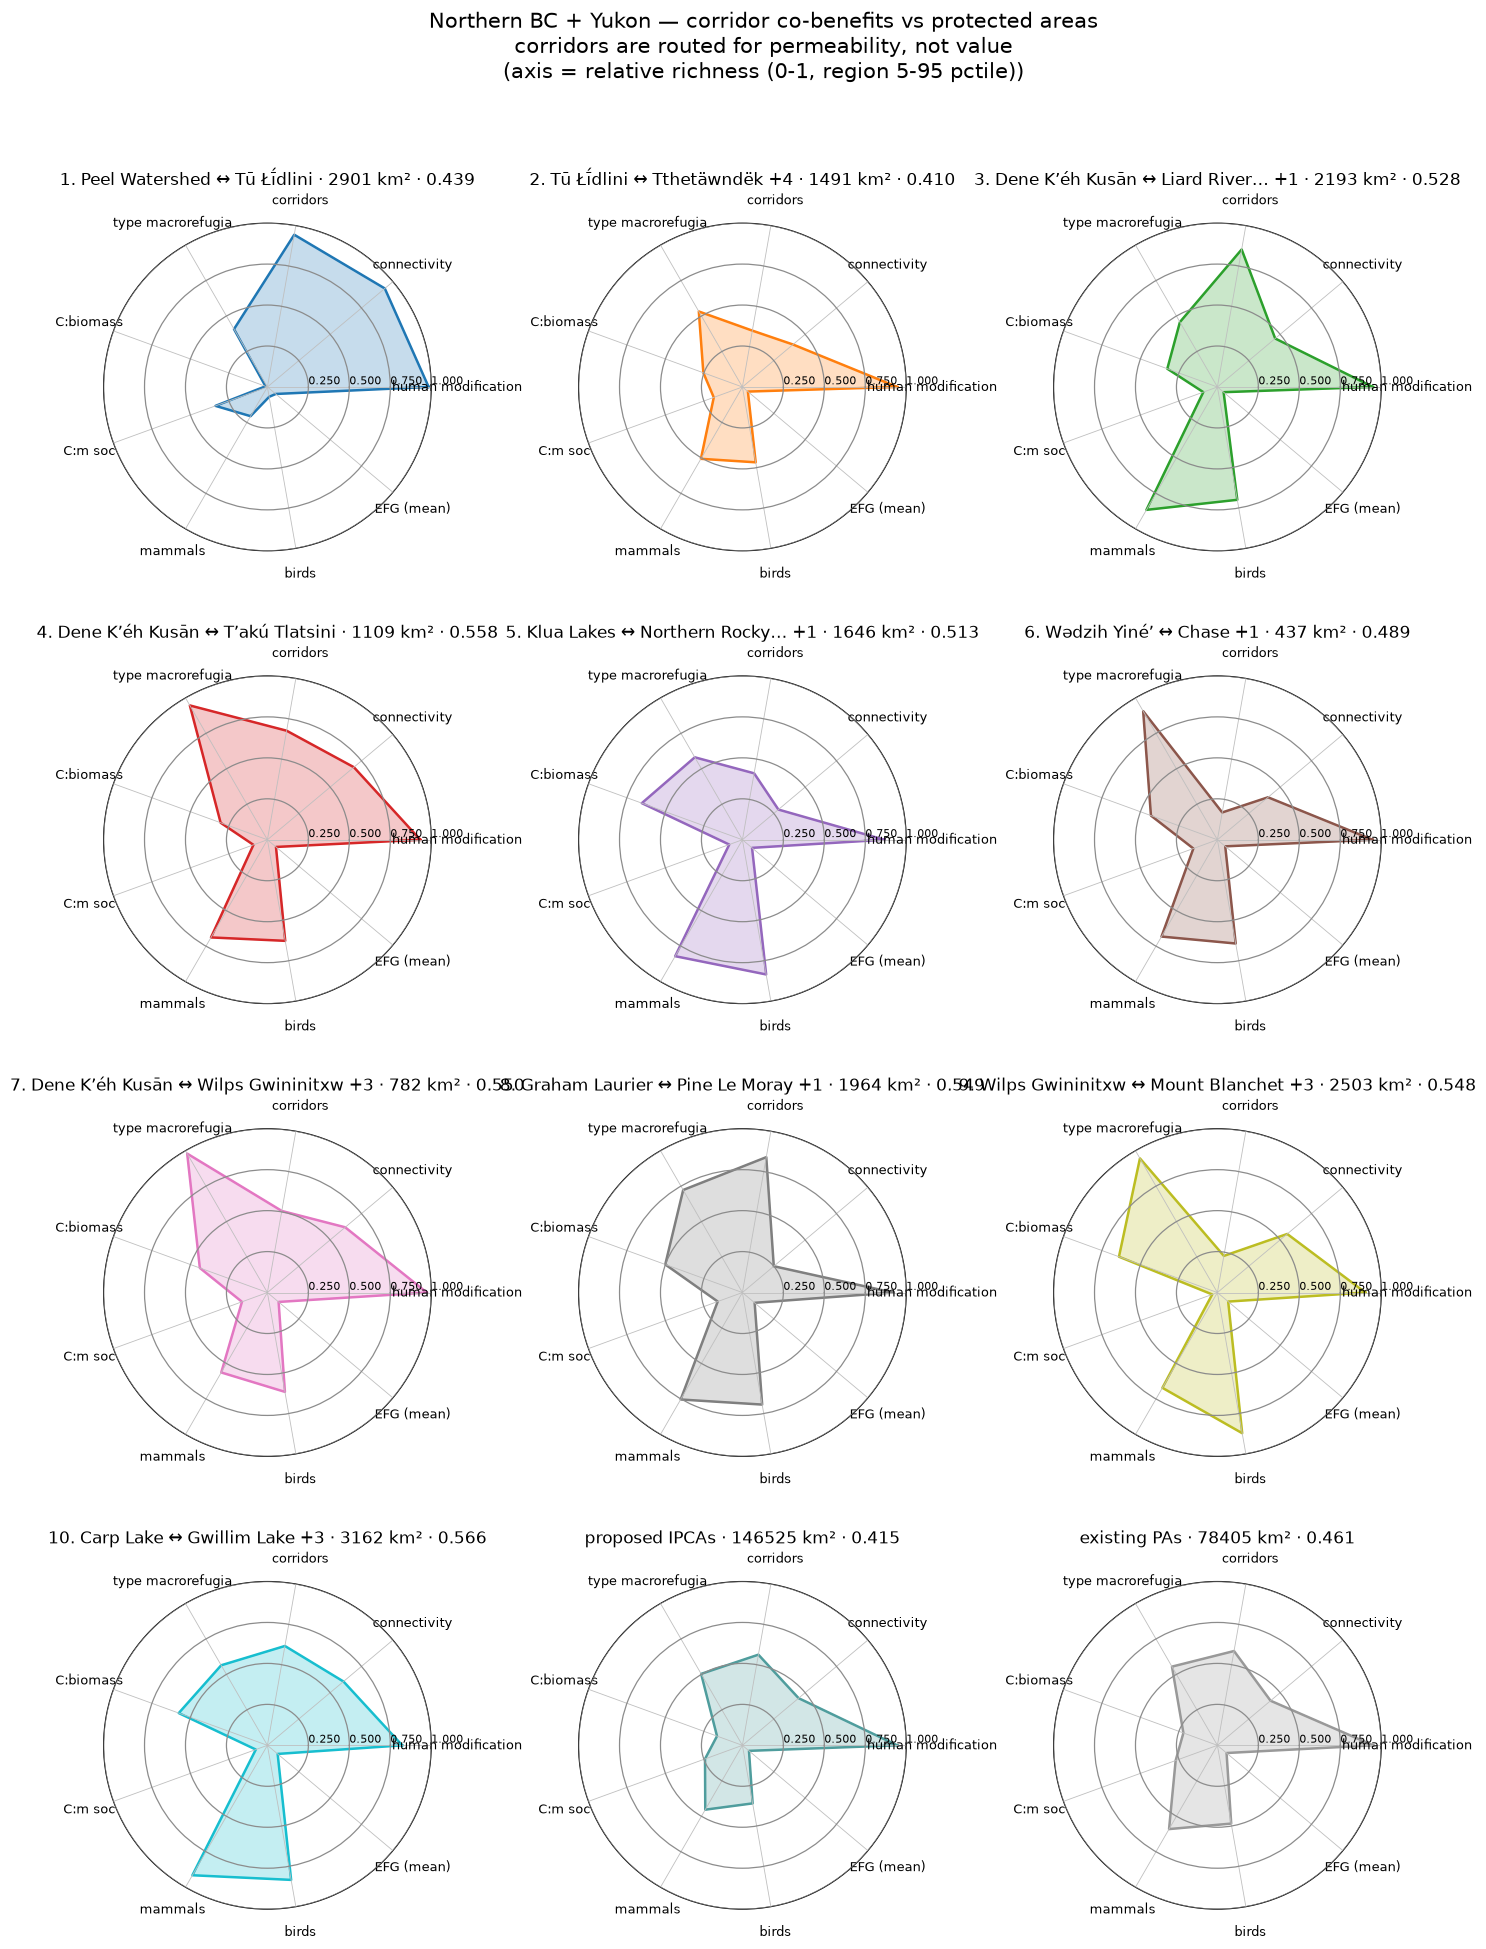

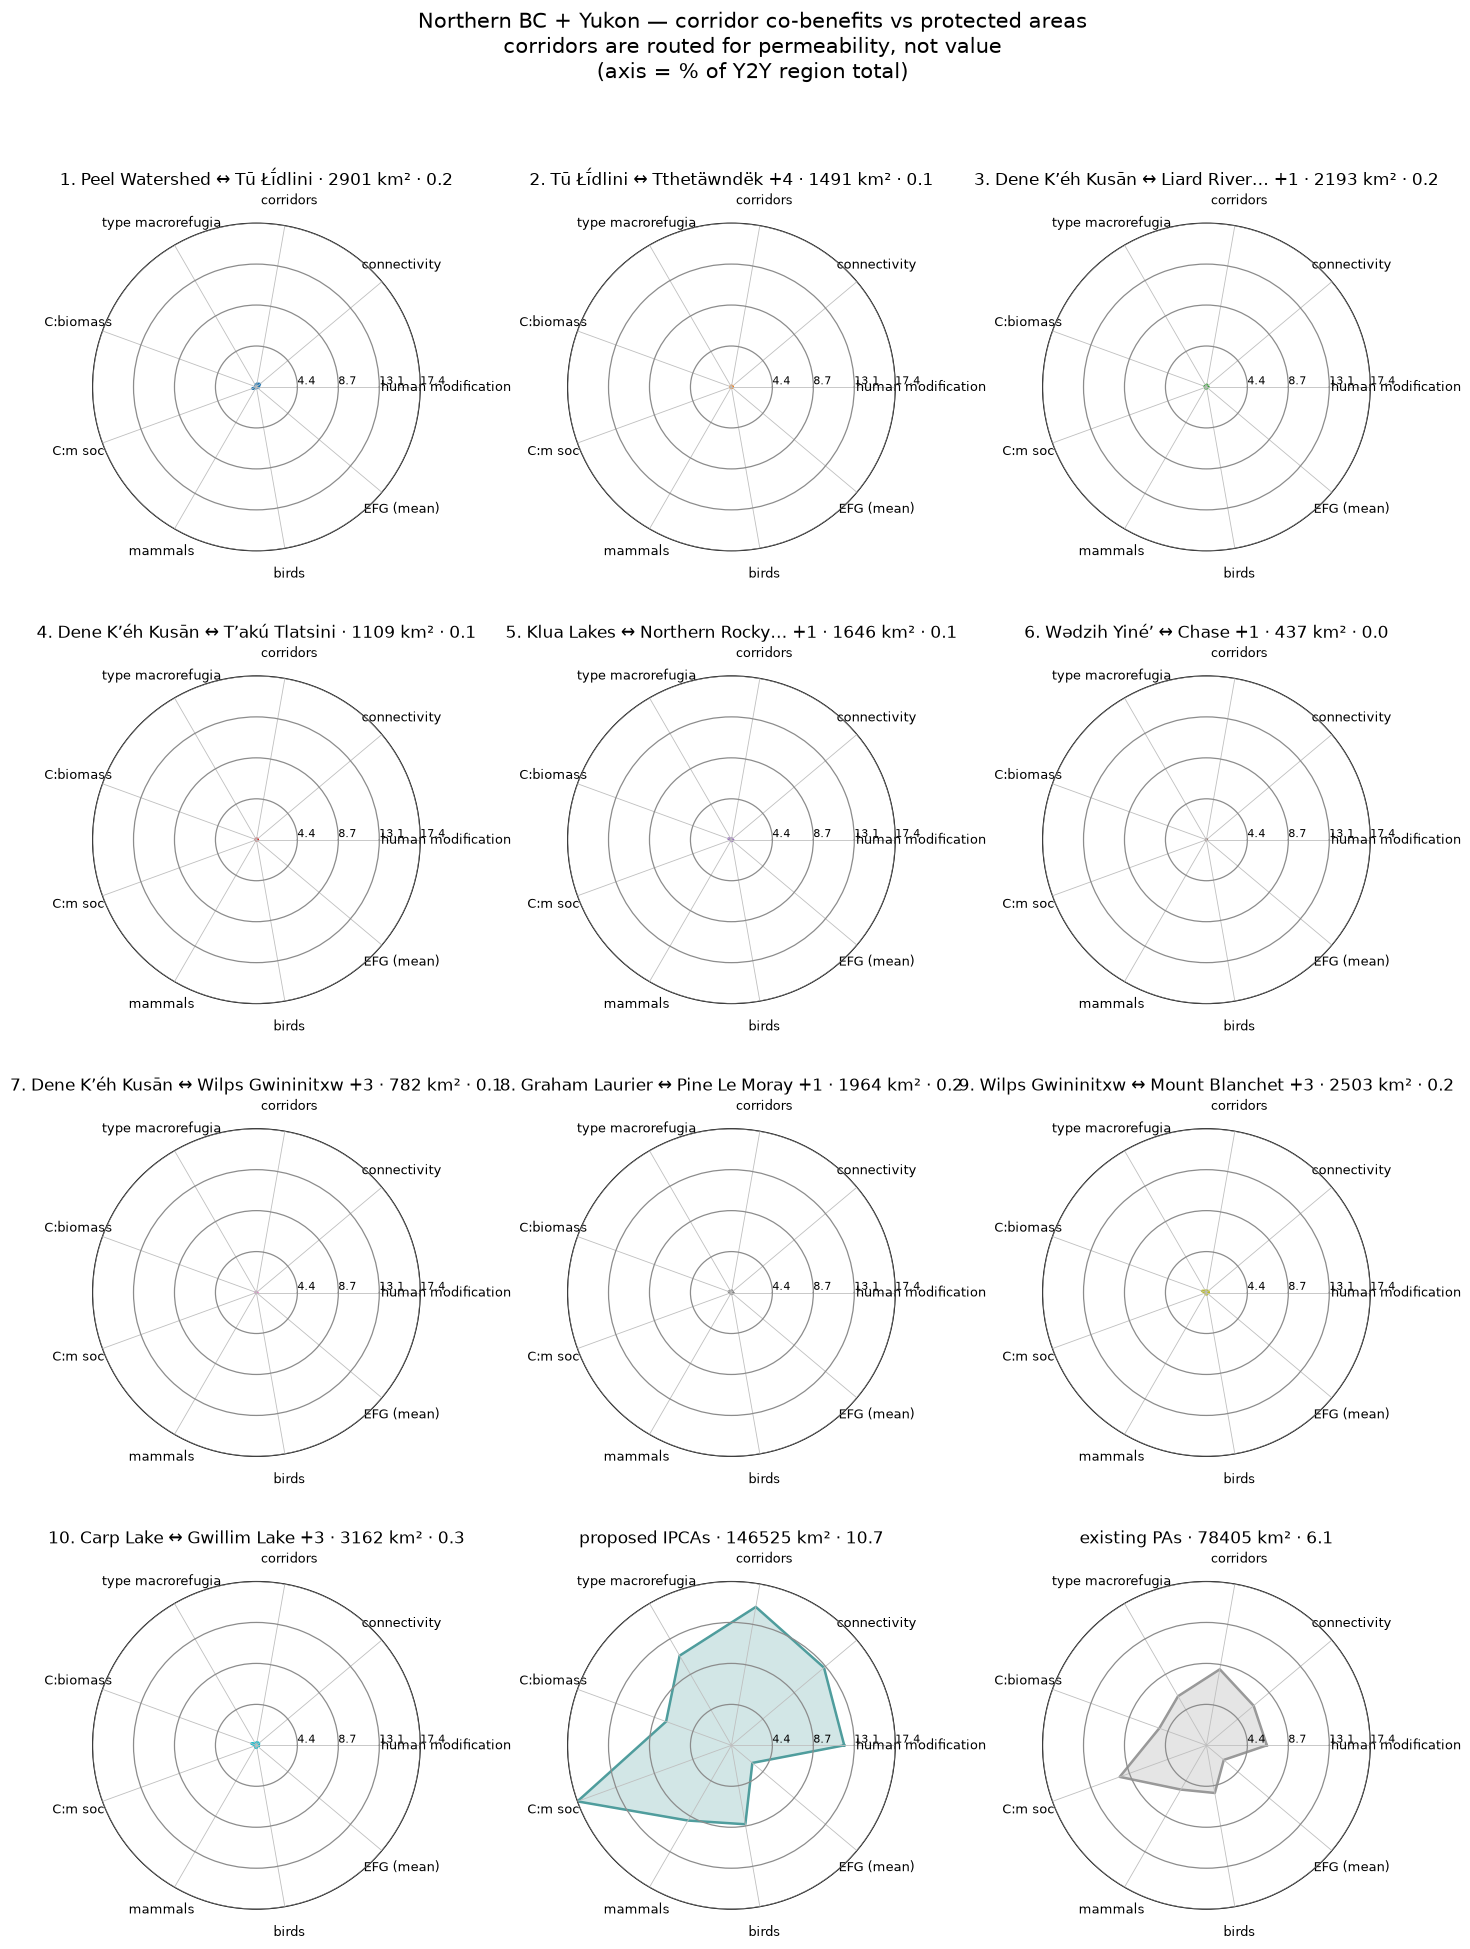

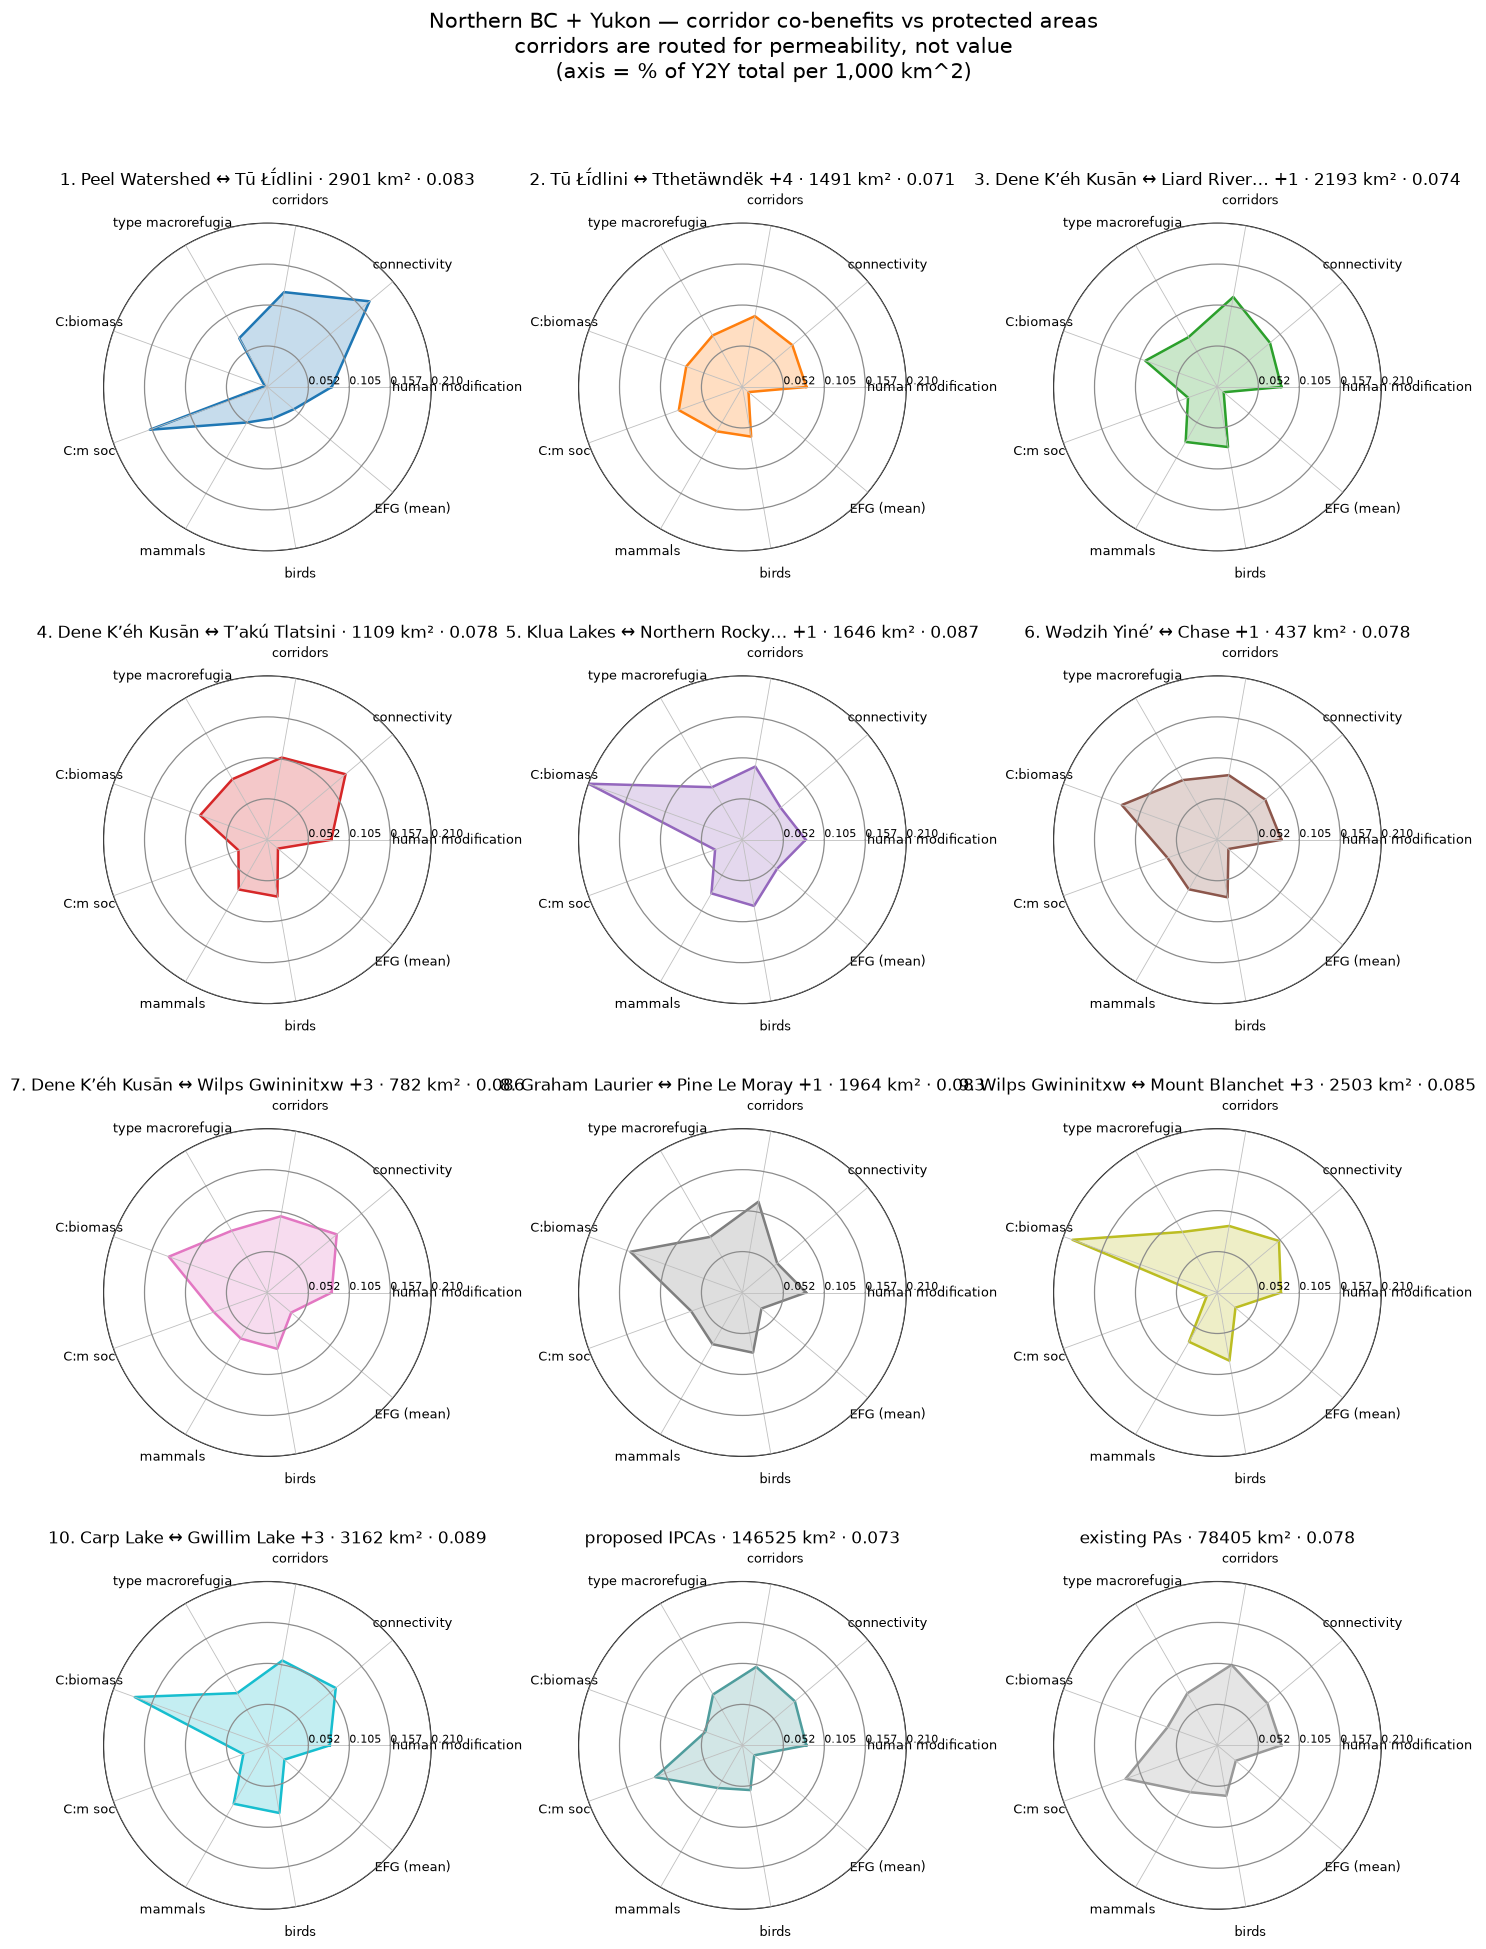

  wrote corridor_profile.csv


<corridors north | 42 nodes | 1286x1730 | corridor 18,188 km² | scenarios: p1_p99, p5_p95 | 10 segments>

In [6]:
# ---- Value star plots: what do the corridors actually carry? ---------------
# A CO-BENEFIT AUDIT, not a scorecard -- the corridors are routed for permeability,
# never for value, so a low carbon/EFG axis is a finding, not a failure.
#
# The corridor is split into the n_groups largest GEOGRAPHIC SEGMENTS: removing the
# node polygons cuts the network at every PA/IPCA, so the connected components ARE
# the physical links between protected areas (23 of them; the top 10 hold ~94% of
# corridor area). Segments are numbered north -> south and named by what they join.
# The IPCAs and existing PAs stay WHOLE units for comparison.
# Pass n_groups=None for the single whole-network corridor profile instead.
#
# Two scalings share these figures:
#   richness                = 0-1 over the NORTHERN window (5-95 pctile)
#   contribution/efficiency = FULL-Y2Y denominators, so literally "% of Y2Y"
# Slow-ish: builds 8 continuous + 40 EFG stacks on the corridor grid (~3 GB peak).
cc.corridor_profile(A, n_groups=10)

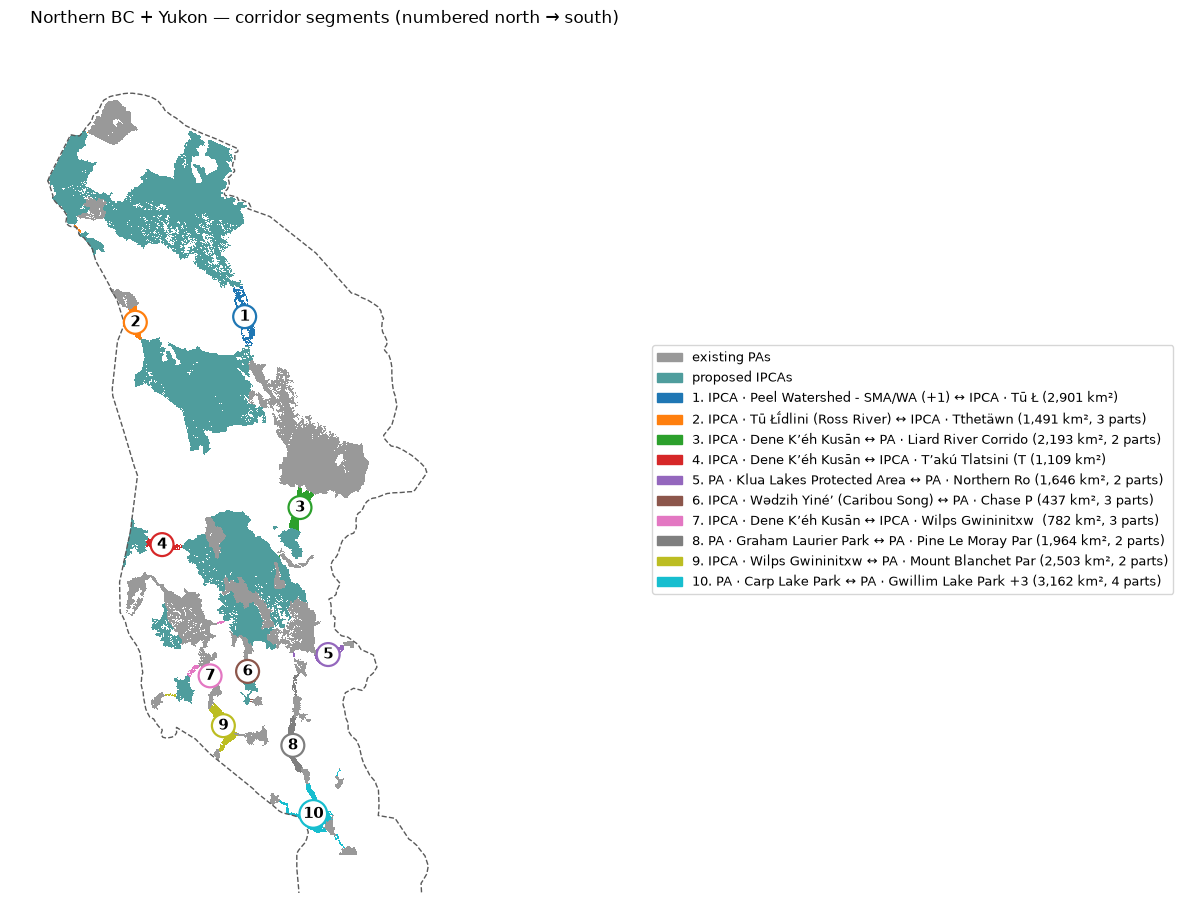

<corridors north | 42 nodes | 1286x1730 | corridor 18,188 km² | scenarios: p1_p99, p5_p95 | 10 segments>

In [7]:
# ---- Numbered map of the corridor segments ---------------------------------
# Reads the SAME A.groups the star plots used, so the numbering can never drift.
# Legend carries the full "X <-> Y" names; the stars use a compact form.
cc.corridor_group_map(A)

In [8]:
# ---- Write outputs ---------------------------------------------------------
# Top level = the PRIMARY scenario (corridors.tif/.gpkg, resistance.tif,
# corridor_frequency.tif, corridors_alt*.gpkg) so existing paths keep working;
# each scenario also gets its own full set in output_data/corridors_north/<scenario>/.
# corridor_summary.json gains a "scenarios" block + pairwise route agreement.
cc.write_outputs(A)

  wrote output_data/corridors_north/corridors.tif
  wrote output_data/corridors_north/resistance.tif
  wrote output_data/corridors_north/corridors.gpkg
  wrote output_data/corridors_north/corridor_frequency.tif
  wrote output_data/corridors_north/corridors_alt1.gpkg
  wrote output_data/corridors_north/corridors_alt2.gpkg
  wrote output_data/corridors_north/corridors_alt3.gpkg
  wrote output_data/corridors_north/p1_p99/corridors.tif
  wrote output_data/corridors_north/p1_p99/resistance.tif
  wrote output_data/corridors_north/p1_p99/corridors.gpkg
  wrote output_data/corridors_north/p1_p99/corridor_frequency.tif
  wrote output_data/corridors_north/p1_p99/corridors_alt1.gpkg
  wrote output_data/corridors_north/p1_p99/corridors_alt2.gpkg
  wrote output_data/corridors_north/p1_p99/corridors_alt3.gpkg
  wrote output_data/corridors_north/p1_p99/corridor_summary.json
  wrote output_data/corridors_north/p5_p95/corridors.tif
  wrote output_data/corridors_north/p5_p95/resistance.tif
  wrote outpu

<corridors north | 42 nodes | 1286x1730 | corridor 18,188 km² | scenarios: p1_p99, p5_p95 | 10 segments>